In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [3]:
#Load dataset
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)

In [6]:
df = pd.DataFrame(mnist.data)
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,147,252,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(70000, 784)

In [9]:
x = mnist.data
y = mnist.target

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(56000, 784)
(14000, 784)
(56000,)
(14000,)


In [13]:
#Create the model
svm_model = SVC(kernel='rbf', gamma ='scale', C=1.0)
#Train the model
svm_model.fit(x_train, y_train)

SVC()

In [15]:
#Prediction
pred = svm_model.predict(x_test)

In [17]:
#Accuracy check
accuracy = accuracy_score(y_test,pred)
accuracy

0.9764285714285714

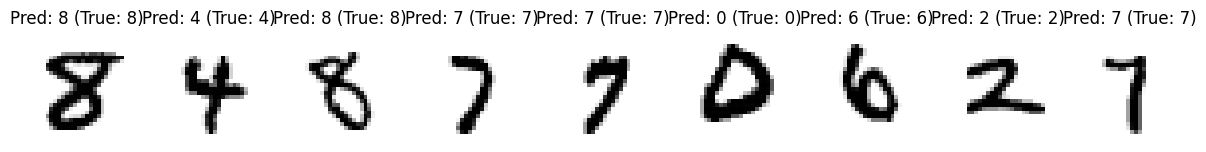

In [30]:
fig, axes = plt.subplots(1, 9, figsize=(15, 5))

for i, ax in enumerate(axes):
    # Since x_test is a DataFrame, we need to take a row using .iloc[i]
# and then convert it to an array with .values before reshaping
    image = x_test.iloc[i].values.reshape(28, 28)

    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')

    # y_test-ও যদি Pandas Series/DataFrame হয়ে থাকে, তবে .iloc দেওয়াই নিরাপদ
    true_label = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
    pred_label = pred[i]

    ax.set_title(f'Pred: {pred_label} (True: {true_label})')
    ax.set_axis_off()

plt.show()

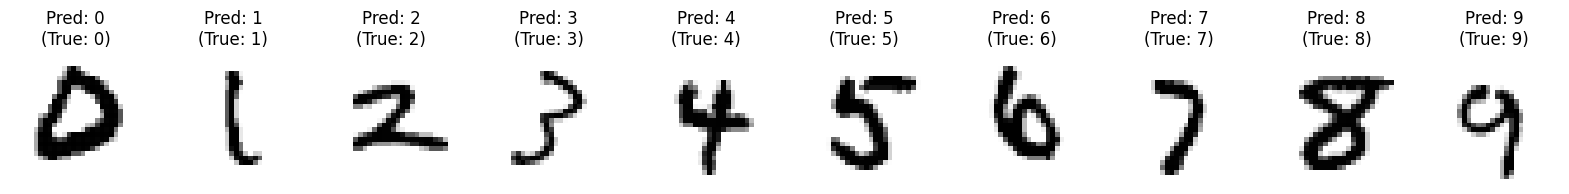

In [38]:
fig, axes = plt.subplots(1, 10, figsize=(20, 3))

# The data inside y_test might be in string format,
# so I'm converting all of them to integers using int() and making a list
y_test_list = [int(y) for y in y_test]

for i, digit in enumerate(range(0, 10)):
    # Now we are sure that there are only numbers inside the list
    idx = y_test_list.index(digit)

    # Extracting the image at that index
    image = x_test.iloc[idx].values.reshape(28, 28)

    # Plotting an image
    axes[i].imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')

    # Actual and Predicted Labels
    true_label = y_test_list[idx]
    pred_label = pred[idx]

    # Setting the Title
    axes[i].set_title(f'Pred: {pred_label}\n(True: {true_label})')
    axes[i].set_axis_off()

# Show last

plt.show()